## 2 electrons in a segment

The time-independent Schrödinger equation for two interacting electrons confined within a segment $[0, L]$ is:

$$
    \left[ - \frac{\hbar^2}{2m} \left( \frac{\partial^2}{\partial x_1^2} + \frac{\partial^2}{\partial x_2^2}\right) +\frac{e^2}{4 \pi \epsilon_0 |x_1 - x_2|} \right] \Psi(x_1,x_2) = E\,\Psi(x_1,x_2) \qquad 0 \leq x_1,\, x_2 \leq L
$$

The boundary conditions are:

$$
    \Psi(0 , x_2)=\Psi(L , x_2) = 0,
    \qquad
    \Psi(x_1 , 0)=\Psi(x_1 , L) = 0
$$

The Pauli principle condition is:

$$
    \Psi(x_1, x_2, \sigma_1, \sigma_2) = - \Psi(x_2, x_1, \sigma_2, \sigma_1)
$$

And $\Psi(x_1, x_2)$ must be normalized:

$$
    \int_{0}^{L} \int_{0}^{L} \, |\Psi(x_1, x_2)|^2 \, dx_1dx_2 = 1
$$

Let's make it fully dimensionless. Introduce:

- $x_1' \triangleq x_1 / L$
- $x_2' \triangleq x_2 / L$
- $E' \triangleq E / \frac{\hbar^2}{2 m L^2}$
- $\Psi'(x_1', x_2') \triangleq \Psi(L x_1', L x_2') / \frac{1}{L}$

We obtain:

$$
    \left[ - \frac{\partial^2}{\partial x_1'^{2}} - \frac{\partial^2}{\partial x_2'^{2}} + \frac{\lambda}{\left| x_1' - x_2' \right|} \right] \Psi'(x_1', x_2') = E' \, \Psi'(x_1', x_2') \qquad 0 \leq x_1', \, x_2' \leq 1
$$

Where $\lambda$ is defined as:

$$
    \lambda \triangleq \frac{2L}{a_{bohr}} \qquad a_{bohr} = \text{Bohr radius}
$$

Conditions:

\begin{cases}
    \Psi(0, x_2')=\Psi(1, x_2') = 0,
    \quad
    \Psi(x_1', 0)=\Psi(x_1', 1) = 0 \qquad \text{Dirichlet conditions} \\\\
    \Psi(x_1', x_2', \sigma_1, \sigma_2) = - \Psi(x_2', x_1', \sigma_2, \sigma_1) \qquad \text{Pauli principle} \\\\
    \int_{0}^{1} \int_{0}^{1} \, \left|\Psi'(x_1', x_2')\right|^2 \, dx_1'dx_2' = 1 \qquad \text{Normalization}
\end{cases}


We're going to solve it numerically using a 5-point-pencil finite difference scheme. Let's proceed step-by-step

In [1]:
import numpy as np
from scipy.sparse import diags_array, kronsum, coo_array
from scipy.sparse.linalg import LaplacianNd, eigsh
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt

In [2]:
# Settings
N = 75 # Number of inner points
N2 = N ** 2
h = 1.0 / (N + 1) # Spacing
lambda_ = 2.0 # lambda constant
epsilon = 0.1 * h # Regularization parameter

The laplacian operator $\frac{\partial^2}{\partial x_1^{2}} + \frac{\partial^2}{\partial x_2'^{2}}$ can be discretize as a tri-diagonal sparse matrix:

$$
    \frac{\partial^2}{\partial x_1^{2}} + \frac{\partial^2}{\partial x_2'^{2}} \rightarrow \text{tridiag}\left( 1, - 2, 1 \right) \triangleq - T
$$

The kinetic part of the hamiltonian is:

$$
    H_{kinetic} = - \frac{1}{h^2} \left(T \oplus T \right) = - \frac{1}{h^2} \left(T \otimes I + I \otimes T \right) \qquad \oplus \rightarrow \text{Kronecker Sum} \quad \otimes \rightarrow \text{Kronecker Product}
$$

Where $h$ is the step size, given by $1 / (N + 1)$ where $N$ is the number of inner points in the grid

In [3]:
T = LaplacianNd( # Building T using LaplacianNd()
    grid_shape = (N,),
    boundary_conditions = 'dirichlet', # Dirichlet conditions applied
    dtype = np.int8
).tosparse().todia() # DIA sparse matrix

T, T.toarray()

(<DIAgonal sparse array of dtype 'int8'
 	with 223 stored elements (3 diagonals) and shape (75, 75)>,
 array([[-2,  1,  0, ...,  0,  0,  0],
        [ 1, -2,  1, ...,  0,  0,  0],
        [ 0,  1, -2, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ..., -2,  1,  0],
        [ 0,  0,  0, ...,  1, -2,  1],
        [ 0,  0,  0, ...,  0,  1, -2]], shape=(75, 75), dtype=int8))

In [4]:
H = ((- 1.0 / h ** 2) * kronsum(T, T)).todia() # Computing H_{kinetic} using kronsum()
H, H.toarray()

(<DIAgonal sparse array of dtype 'float64'
 	with 27973 stored elements (5 diagonals) and shape (5625, 5625)>,
 array([[23104., -5776.,     0., ...,     0.,     0.,     0.],
        [-5776., 23104., -5776., ...,     0.,     0.,     0.],
        [    0., -5776., 23104., ...,     0.,     0.,     0.],
        ...,
        [    0.,     0.,     0., ..., 23104., -5776.,     0.],
        [    0.,     0.,     0., ..., -5776., 23104., -5776.],
        [    0.,     0.,     0., ...,     0., -5776., 23104.]],
       shape=(5625, 5625)))

The Coulomb potential matrix is defined as follows:

$$
    V_{ij} \triangleq \frac{\lambda}{h \left| i - j \right|} \qquad 1 \leq i, \, j
$$

To handle numerically the singularity at $i = j$, we slightly modify it:

$$
    V_{ij} \triangleq \frac{\lambda}{\sqrt{h^2 \left(i - j \right)^2 + \delta^2}} \qquad 1 \leq i, \, j
$$

Where $\delta$ is a fraction of $h$.

$V_{ij}$ is a symmetric Toeplitz matrix. We can build and flat it easily to match the same dimensions of $H_{kinetic}$

In [5]:
i_minus_j = np.arange(0, N, 1, dtype = np.int8) # | i - j | = 0, 1, 2, 3, ..., N - 1
rc = lambda_ / np.sqrt((h * i_minus_j) ** 2 + epsilon ** 2) # Row or column of Toeplitz matrix
V = toeplitz(r = rc, c = rc) # Computing V using Toeplitz()
V

array([[1520.        ,  151.24565291,   75.90517775, ...,    2.11110907,
           2.08218983,    2.05405218],
       [ 151.24565291, 1520.        ,  151.24565291, ...,    2.14084295,
           2.11110907,    2.08218983],
       [  75.90517775,  151.24565291, 1520.        , ...,    2.17142636,
           2.14084295,    2.11110907],
       ...,
       [   2.11110907,    2.14084295,    2.17142636, ..., 1520.        ,
         151.24565291,   75.90517775],
       [   2.08218983,    2.11110907,    2.14084295, ...,  151.24565291,
        1520.        ,  151.24565291],
       [   2.05405218,    2.08218983,    2.11110907, ...,   75.90517775,
         151.24565291, 1520.        ]], shape=(75, 75))

Let's flat it. We define $V$ as the diagonal of a sparse diagonal matrix which contains the Toeplitz's coefficients

In [6]:
V = diags_array(
    V.ravel(), # V flatten
    shape = (H.shape[0], H.shape[0]), # Same shape of H_{kinetic}
    format = 'dia',
    dtype = np.float64
)

V, V.toarray()

(<DIAgonal sparse array of dtype 'float64'
 	with 5625 stored elements (1 diagonals) and shape (5625, 5625)>,
 array([[1520.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,  151.24565291,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,    0.        ,   75.90517775, ...,    0.        ,
            0.        ,    0.        ],
        ...,
        [   0.        ,    0.        ,    0.        , ...,   75.90517775,
            0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
          151.24565291,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        , 1520.        ]], shape=(5625, 5625)))

We can build the full hamiltonian. Add $H_{kinetic}$ and $V$

In [7]:
# Full hamiltonian: H_{kinetic} + V
H += V
H, H.toarray()

(<DIAgonal sparse array of dtype 'float64'
 	with 27973 stored elements (5 diagonals) and shape (5625, 5625)>,
 array([[24624.        , -5776.        ,     0.        , ...,
             0.        ,     0.        ,     0.        ],
        [-5776.        , 23255.24565291, -5776.        , ...,
             0.        ,     0.        ,     0.        ],
        [    0.        , -5776.        , 23179.90517775, ...,
             0.        ,     0.        ,     0.        ],
        ...,
        [    0.        ,     0.        ,     0.        , ...,
         23179.90517775, -5776.        ,     0.        ],
        [    0.        ,     0.        ,     0.        , ...,
         -5776.        , 23255.24565291, -5776.        ],
        [    0.        ,     0.        ,     0.        , ...,
             0.        , -5776.        , 24624.        ]],
       shape=(5625, 5625)))

As we can see, $H$ is a penta-diagonal sparse matrix.

We introduce the permutation matrix $P$, that swaps $x_1$ with $x_2$ and viceversa:

$$
    P \, \Psi(x_1, x_2) \triangleq \Psi(x_2, x_1)
$$

In our context:

$$
    P \, \Psi_{ij} = \Psi_{ji}
$$

$H$ commutes with $P$, then they share a set of eigenvectors. We shall solve this system of eigenvalue equations:

\begin{cases}
    H \Psi = E' \Psi \\
    P \Psi = \pm \Psi
\end{cases}

We can easily solve the second equation (because the eigenvalues of $P$ are just $\pm 1$), build the matrix $U$ (manually, no choice...) that diagonalizes $P$ and then solve $H \Psi = E' \Psi$ in the new basis defined by $U$. Symmetric and antisymmetric eigenvectors will arise naturally if we split $U$ in $U_{sym}$ and $U_{asym}$.

The columns of $U_{sym}$ are the eigenvectors of $U$ when the eigenvalue is equal to 1.

$U_{sym}$ diagonalizes $P$ and reduces it:

$$
    U_{sym}^{T} P U_{sym} = \, \text{Diagonal form of P, reduced}
$$

$H$ written with $U_{sym}$ is just:

$$
    H_{sym} = U_{sym}^{T} H U_{sym}
$$

And it will yield symmetric states. Analogous for $U_{asym}$

Due the Pauli principle, the spatial wavefunction $\Psi(x_1, x_2)$ is symmetric when the total spin is in the singlet state; the spatial wavefunction is antisymmetric when the total spin is the triplet state

In [8]:
# Building U matrices manually. It's impossible otherwise... we can't find all eigenvectors using scipy capabilities
# We do not need P explicity to compute U_sym and U_asym

M = N * (N - 1) // 2
r = 1.0 / np.sqrt(2.0)

# Pair positions (i < j), row-major
iu, ju = np.triu_indices(N, k = 1)
up = (iu * N + ju).astype(np.int16)
lo = (ju * N + iu).astype(np.int16)

# Row indices shared by the off-diagonal blocks of both U_sym and U_asym
off_r = np.empty(2 * M, dtype = np.int16)
off_r[0::2] = up
off_r[1::2] = lo

# U_sym: N diagonal cols + M symmetric cols
sym_r = np.empty(N + 2 * M, dtype = np.int16)
sym_r[:N] = np.arange(N, dtype = np.int16) * (N + 1)
sym_r[N:] = off_r

sym_c = np.empty(N + 2 * M, dtype = np.int16)
sym_c[:N] = np.arange(N, dtype = np.int16)
sym_c[N:] = np.repeat(N + np.arange(M, dtype = np.int16), 2)

sym_v = np.empty(N + 2 * M, dtype = np.float64)
sym_v[:N] = 1.0
sym_v[N:] = r

U_sym = coo_array((sym_v, (sym_r, sym_c)), shape = (N2, N + M)).tocsr()

# U_asym: M antisymmetric cols
asym_c = np.repeat(np.arange(M, dtype = np.int16), 2)
asym_v = np.empty(2 * M, dtype = np.float64)
asym_v[0::2] = r
asym_v[1::2] = - r

U_asym = coo_array((asym_v, (off_r, asym_c)), shape = (N2, M)).tocsr()

U_sym, U_sym.toarray(), U_asym, U_asym.toarray() # Display

(<Compressed Sparse Row sparse array of dtype 'float64'
 	with 5625 stored elements and shape (5625, 2850)>,
 array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.70710678,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.70710678],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(5625, 2850)),
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 5550 stored elements and shape (5625, 2775)>,
 array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.70710678,  0.        ,  0.        , ...,  0.        ,
   

Let's transform the hamiltonian applying a similarity transformation

In [9]:
H = H.tocsr() # Convert H into CSR format

H_sym = U_sym.T @ (H @ U_sym) # H_sym for symmetric eigenvectors
H_asym = U_asym.T @ (H @ U_asym) # H_asym for antisymmetric eigenvectors

H_sym, H_sym.toarray(), H_asym, H_asym.toarray()

(<Compressed Sparse Column sparse array of dtype 'float64'
 	with 13950 stored elements and shape (2850, 2850)>,
 array([[24624.        ,     0.        ,     0.        , ...,
             0.        ,     0.        ,     0.        ],
        [    0.        , 24624.        ,     0.        , ...,
             0.        ,     0.        ,     0.        ],
        [    0.        ,     0.        , 24624.        , ...,
             0.        ,     0.        ,     0.        ],
        ...,
        [    0.        ,     0.        ,     0.        , ...,
         23255.24565291, -5776.        ,     0.        ],
        [    0.        ,     0.        ,     0.        , ...,
         -5776.        , 23179.90517775, -5776.        ],
        [    0.        ,     0.        ,     0.        , ...,
             0.        , -5776.        , 23255.24565291]],
       shape=(2850, 2850)),
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 13579 stored elements and shape (2775, 2775)>,
 array([[232

Finally we can solve the Schrodinger equation

In [10]:
E_sym, psi_sym = eigsh( # Symmetric eigenvectors
    H_sym,
    k = 3, # Just 3
    which = 'SM'
)

E_asym, psi_asym = eigsh( # Antisymmetric eigenvectors
    H_asym,
    k = 3, # Just 3
    which = 'SM'
)

In [11]:
E_sym, E_asym # Energy prime for symmetric and antisymmetric states

(array([ 47.0434655 ,  88.89382286, 112.52080457]),
 array([ 55.68371667, 106.5422576 , 135.35006439]))

Let's normalize it. We can write:

$$
    \iint_{0}^{1} \, \left| \Psi'(x_1', x_2') \right|^2 \, dx_1' dx_2' \approx h^2 \, \sum_{i, j} \left| \Psi_{ij}' \right|^2 \, \text{must be 1}
$$

scipy.linalg.eigsh returns normalized vectors:

$$
    \sum_{i, j} \left| \Psi_{ij}' \right|^2 = 1
$$

To normalize, with should divide the results yielded by $h$

In [12]:
# Normalization
psi_sym /= h
psi_asym /= h

$H_{sym}$ yields the symmetric eigenvectors whose coordinates are written in the basis of eigenvectors of P, when the eigenvalue is equal to 1. Similarly, $H_{asym}$ yields the antisymmetric eigenvectors whose coordinates are written in the basis of eigenvectors of P, when the eigenvalue is equal to -1. We need to change the basis to "canonical".

To do so, just apply $U_{sym}$ and U_{asym}:

$$
    \Psi_{sym}^{full} = U_{sym} \Psi_{sym}^{reduced}
$$

$\quad$

$$
    \Psi_{asym}^{full} = U_{asym} \Psi_{asym}^{reduced}
$$

In this way, they are naturally reshaped

In [13]:
# Full eigenvectors, matching the grid
psi_sym = [U_sym @ psi_sym[:, j] for j in range(psi_sym.shape[1])]
psi_asym = [U_asym @ psi_asym[:, j] for j in range(psi_asym.shape[1])]

In [14]:
psi_sym, psi_asym # Final solutions

([array([-0.00064148, -0.00136476, -0.00219038, ..., -0.00219038,
         -0.00136476, -0.00064148], shape=(5625,)),
  array([ 0.00247583,  0.00525838,  0.00841495, ..., -0.00841495,
         -0.00525838, -0.00247583], shape=(5625,)),
  array([0.00288146, 0.006114  , 0.00976798, ..., 0.00976798, 0.006114  ,
         0.00288146], shape=(5625,))],
 [array([ 0.00000000e+00,  2.02822119e-05,  8.14644100e-05, ...,
         -8.14644100e-05, -2.02822119e-05,  0.00000000e+00], shape=(5625,)),
  array([0.00000000e+00, 8.37594583e-05, 3.35686090e-04, ...,
         3.35686090e-04, 8.37594583e-05, 0.00000000e+00], shape=(5625,)),
  array([ 0.        , -0.00010295, -0.00041208, ...,  0.00041208,
          0.00010295,  0.        ], shape=(5625,))])

Let's plot it all

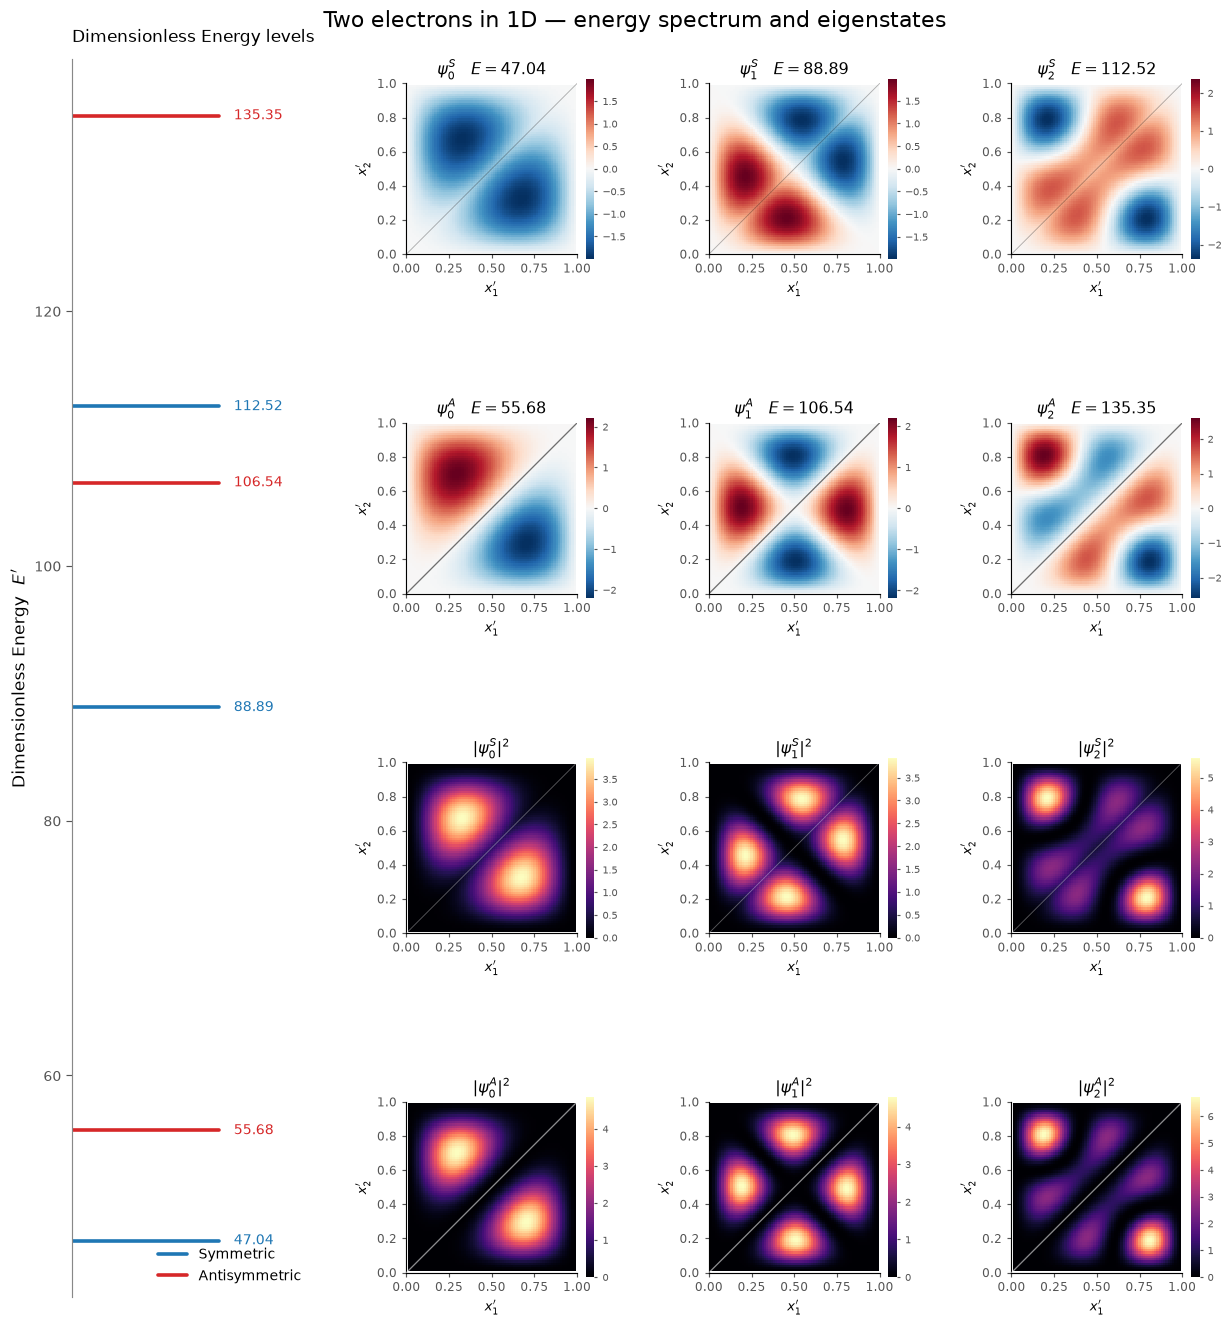

In [15]:
# Grid & coordinate mesh
x = (np.arange(0, N, 1) + 1) * h
X1, X2 = np.meshgrid(x, x, indexing = 'ij')

n_sym  = len(E_sym)
n_asym = len(E_asym)
n_cols = max(n_sym, n_asym)

# Figure + GridSpec
fig = plt.figure(figsize = (3.0 * n_cols + 3.0, 13.5))
gs = fig.add_gridspec(4, n_cols + 1, width_ratios = [1.15] + [1] * n_cols, hspace = 0.55, wspace = 0.42, left = 0.05, right = 0.97, top = 0.93, bottom = 0.05)

# Left column: energy levels (spans all 4 rows)
ax_E = fig.add_subplot(gs[:, 0])

for n, E in enumerate(E_sym):
    ax_E.plot([0, 1], [E, E], color = '#1f77b4', lw = 2.5, solid_capstyle = 'round', label = 'Symmetric' if n == 0 else None)
    ax_E.text(1.10, E, f'{E:.2f}', va = 'center', ha = 'left', color = '#1f77b4', fontsize = 10)

for n, E in enumerate(E_asym):
    ax_E.plot([0, 1], [E, E], color = '#d62728', lw = 2.5, solid_capstyle = 'round', label = 'Antisymmetric' if n == 0 else None)
    ax_E.text(1.10, E, f'{E:.2f}', va = 'center', ha = 'left', color = '#d62728', fontsize = 10)

ax_E.set_xlim(0, 1.65)
ax_E.set_xticks([])
ax_E.set_ylabel("Dimensionless Energy  $E'$", fontsize = 12)
ax_E.set_title('Dimensionless Energy levels', fontsize = 12, pad = 12)
for s in ['top', 'right', 'bottom']: ax_E.spines[s].set_visible(False)
ax_E.spines['left'].set_color('#888')
ax_E.tick_params(axis = 'y', colors = '#555', length = 4)
ax_E.legend(frameon = False, loc = 'lower right', fontsize = 10)

# Helper: style a 2D panel to match the rest of the notebook
def style_2d(ax, title):
    ax.set_aspect('equal')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(r"$x_1'$", fontsize = 9)
    ax.set_ylabel(r"$x_2'$", fontsize = 9)
    ax.set_title(title, fontsize = 11)
    ax.tick_params(colors = '#555', length = 3, labelsize = 8)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def draw_signed(ax, psi_1d, title, diagonal_lw = 0.6, diagonal_alpha = 0.3):
    psi = psi_1d.reshape(N, N)
    vmax = np.abs(psi).max()
    im = ax.pcolormesh(X1, X2, psi, cmap = 'RdBu_r', shading = 'auto', vmin = - vmax, vmax = vmax, rasterized = True)
    ax.plot([0, 1], [0, 1], color = 'k', lw = diagonal_lw, alpha = diagonal_alpha, zorder = 3)
    style_2d(ax, title)
    cb = fig.colorbar(im, ax = ax, shrink = 0.82, pad = 0.04)
    cb.outline.set_visible(False)
    cb.ax.tick_params(colors = '#555', length = 2, labelsize = 7)

def draw_density(ax, psi_1d, title, diagonal_lw = 0.6, diagonal_alpha = 0.35):
    rho = np.abs(psi_1d.reshape(N, N)) ** 2
    im = ax.pcolormesh(X1, X2, rho, cmap = 'magma', shading = 'auto', vmin = 0, rasterized = True)
    ax.plot([0, 1], [0, 1], color = 'w', lw = diagonal_lw, alpha = diagonal_alpha, zorder = 3)
    style_2d(ax, title)
    cb = fig.colorbar(im, ax = ax, shrink = 0.82, pad = 0.04)
    cb.outline.set_visible(False)
    cb.ax.tick_params(colors = '#555', length = 2, labelsize = 7)

# Row 0: signed symmetric wavefunctions
for k in range(n_sym):
    ax = fig.add_subplot(gs[0, k + 1])
    draw_signed(ax, psi_sym[k], rf'$\psi^{{S}}_{{{k}}}$   $E = {E_sym[k]:.2f}$')

# Row 1: signed antisymmetric wavefunctions
for k in range(n_asym):
    ax = fig.add_subplot(gs[1, k + 1])
    draw_signed(ax, psi_asym[k], rf'$\psi^{{A}}_{{{k}}}$   $E = {E_asym[k]:.2f}$', diagonal_lw = 0.9, diagonal_alpha = 0.55)

# Row 2: symmetric probability densities
for k in range(n_sym):
    ax = fig.add_subplot(gs[2, k + 1])
    draw_density(ax, psi_sym[k], rf'$|\psi^{{S}}_{{{k}}}|^2$')

# Row 3: antisymmetric probability densities
for k in range(n_asym):
    ax = fig.add_subplot(gs[3, k + 1])
    draw_density(ax, psi_asym[k], rf'$|\psi^{{A}}_{{{k}}}|^2$', diagonal_lw = 0.9, diagonal_alpha = 0.55)

# Title
fig.suptitle('Two electrons in 1D — energy spectrum and eigenstates', fontsize = 15, y = 0.965)

plt.show()